In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns 

# Set seed for reproducibility
np.random.seed(42)

# Generate realistic data
n_rows = 180
cities = np.random.choice(["Taipei", "New York", "London"], size=n_rows)
seasons = np.random.choice(["Summer", "Winter"], size=n_rows)
boba_types = np.random.choice(["Classic Milk Tea", "Fruit Tea"], size=n_rows)

# Base temperature depending on city and season
temp = []
for city, season in zip(cities, seasons):
    if season == "Summer":
        temp.append(np.random.normal(30 if city == "Taipei" else 25, 3))
    else:
        temp.append(np.random.normal(15 if city == "Taipei" else 5, 4))

# Base sales depending on temperature, boba type, and city
sales = []
for t, b_type, city in zip(temp, boba_types, cities):
    base = 150 if city == "New York" else (120 if city == "London" else 100)
    # Fruit tea sells incredibly well when it's hot; Milk tea is steady
    if b_type == "Fruit Tea":
        sale_val = base + (t * 4.5) + np.random.normal(0, 15)
    else:
        sale_val = base + 50 + (t * 0.8) + np.random.normal(0, 10)
    sales.append(round(sale_val, 2))

# Create DataFrame
df = pd.DataFrame({
    "City": cities,
    "Season": seasons,
    "Boba_Type": boba_types,
    "Temperature_C": [round(t, 1) for t in temp],
    "Daily_Sales_USD": sales,
    "Customer_Rating": np.random.uniform(3.5, 5.0, size=n_rows).round(1)
})

# Quick preview
(df.head())

,City,Season,Boba_Type,Temperature_C,Daily_Sales_USD,Customer_Rating
0,London,Summer,Classic Milk Tea,18.9,200.65,3.7
1,Taipei,Summer,Fruit Tea,30.6,239.25,4.8
2,London,Winter,Classic Milk Tea,2.4,183.68,3.7
3,London,Summer,Fruit Tea,27.6,245.02,4.1
4,Taipei,Winter,Classic Milk Tea,11.8,180.07,4.7


# Faceting

<Figure size 1000x10000 with 0 Axes>

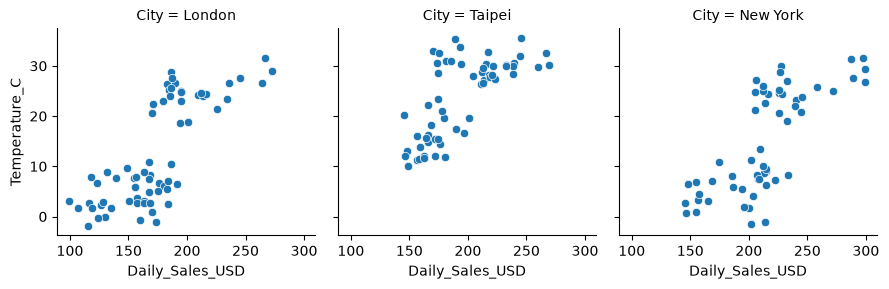

In [15]:
plt.figure(figsize=(10,100))
g = sns.FacetGrid(col="City", data = df)
g.map_dataframe(
    sns.scatterplot,
    x = "Daily_Sales_USD",
    y = "Temperature_C"
)

plt.show()

<Figure size 1000x10000 with 0 Axes>

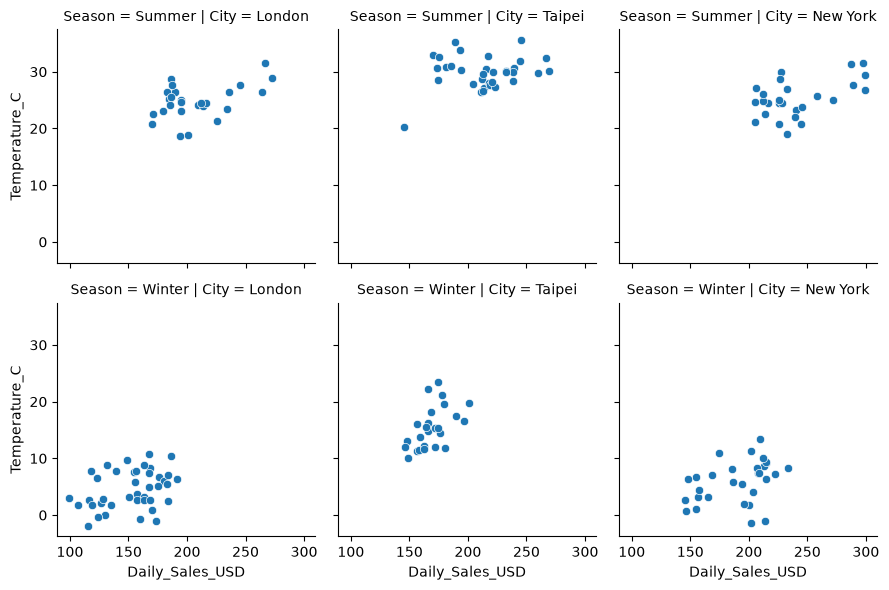

In [16]:
plt.figure(figsize=(10,100))
g = sns.FacetGrid(col="City",row="Season", data = df)
g.map_dataframe(
    sns.scatterplot,
    x = "Daily_Sales_USD",
    y = "Temperature_C"
)

plt.show()

# Relation Plot

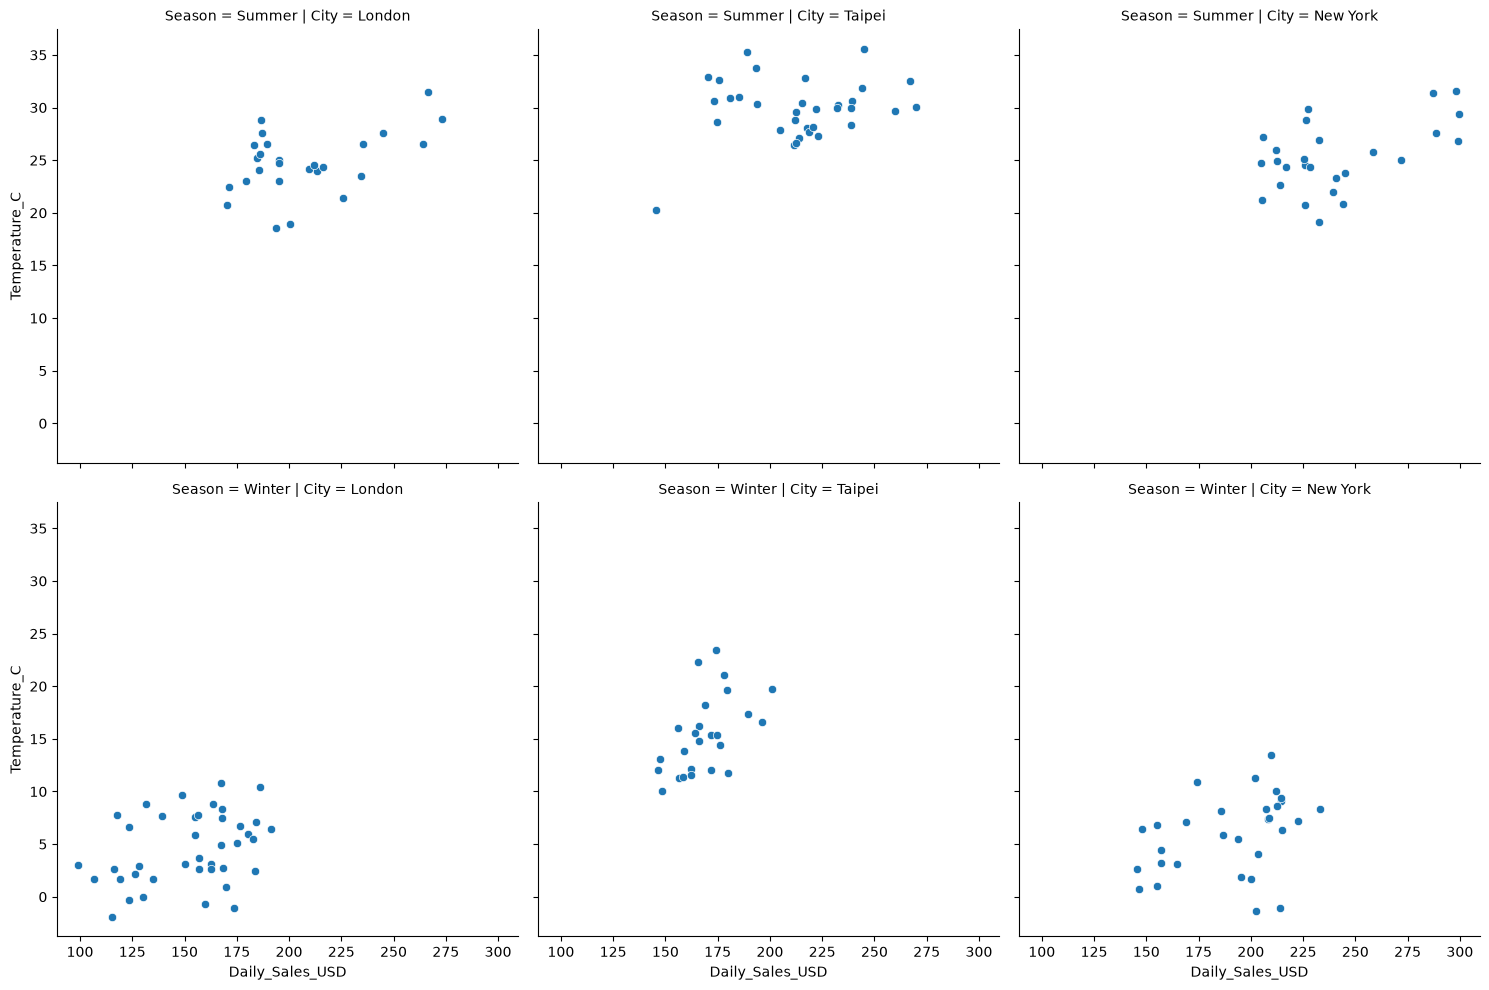

In [25]:
sns.relplot(
    data=df,
     x = "Daily_Sales_USD",
     y = "Temperature_C",
     col = "City",
     row="Season"
)

plt.show()
# Automatically Adjusts Size thereby no overlapping

# Pair Plot

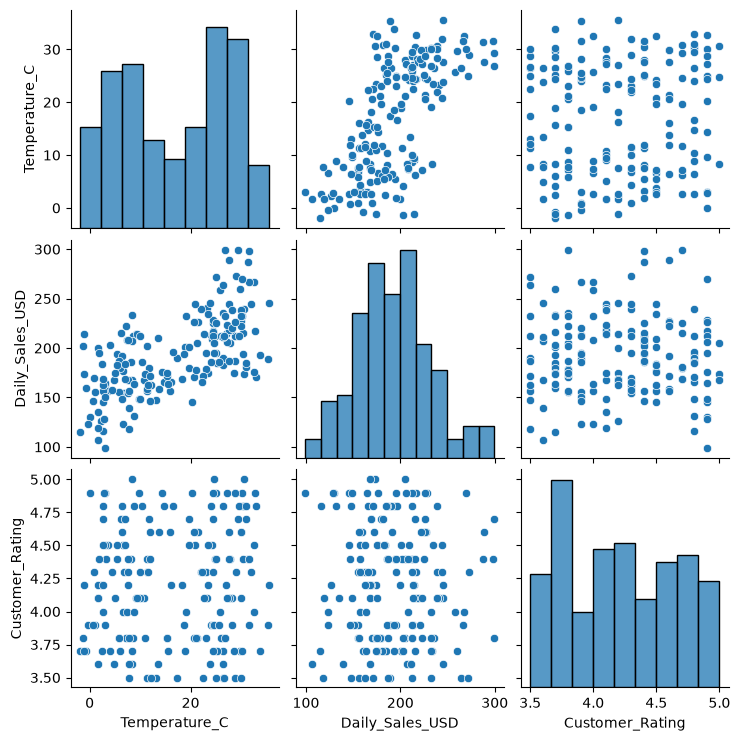

In [26]:
sns.pairplot(df)
plt.show()

# Hue

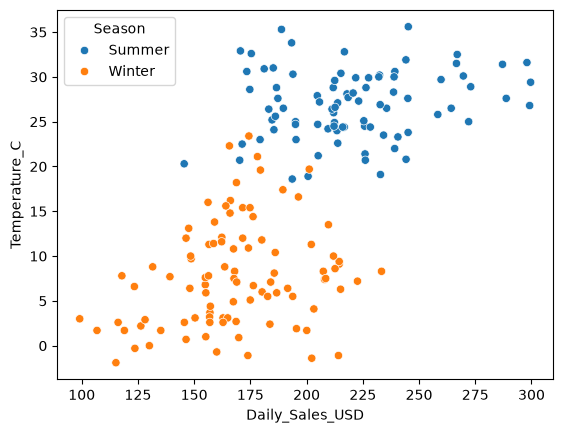

In [27]:
sns.scatterplot(
    data = df,
    x = "Daily_Sales_USD",
    y = "Temperature_C",
    hue = "Season"
)

plt.show()

# 📊 EDA Revision — Visualizing Multiple Variables

## 🎯 Goal
Visualize relationships involving **3 or more variables** using categorical variables to split or color plots.

---

# 1. Faceting (Conditioning)

Split one graph into multiple smaller graphs based on a categorical variable.

**Example:**
- Area vs Price for each City
- Marks vs Study Hours for each Department

```python
g = sns.FacetGrid(df, col="Department")
g.map_dataframe(sns.scatterplot,
                x="Study_Hours",
                y="Marks")
```

### Parameters
- `col` → Split into columns
- `row` → Split into rows
- `col_wrap` → Wrap columns into multiple rows

---

# 2. Hue

Instead of separate graphs, use colors to represent categories.

```python
sns.scatterplot(
    data=df,
    x="Study_Hours",
    y="Marks",
    hue="Department"
)
```

✔ One graph, different colors.

---

# 3. relplot()

High-level Seaborn function for relational plots.

```python
sns.relplot(
    data=df,
    x="Study_Hours",
    y="Marks",
    col="Department",
    hue="Gender"
)
```

Internally uses **FacetGrid**.

---

# 4. Pairplot

Shows pairwise relationships between **all numeric variables**.

```python
sns.pairplot(df)
```

### Features
- Scatterplots for every numeric pair
- Diagonal shows distribution (Histogram/KDE)

Useful for quick exploratory analysis.

---

# When to Use

| Technique | Best For |
|-----------|----------|
| **Hue** | Few categories, minimal overlap |
| **FacetGrid** | Many categories or overlapping data |
| **Pairplot** | Explore relationships among all numeric features |
| **relplot** | Quick faceted relational plots |

---

# Key Takeaways

- **Conditioning = Split plots by categorical variables.**
- **Hue = Color-code categories in one plot.**
- **FacetGrid = Multiple subplots for comparison.**
- **Pairplot = Automatic scatterplot matrix for numeric columns.**
- **relplot = Convenient wrapper around FacetGrid for scatter/line plots.**